Ground Track Plot

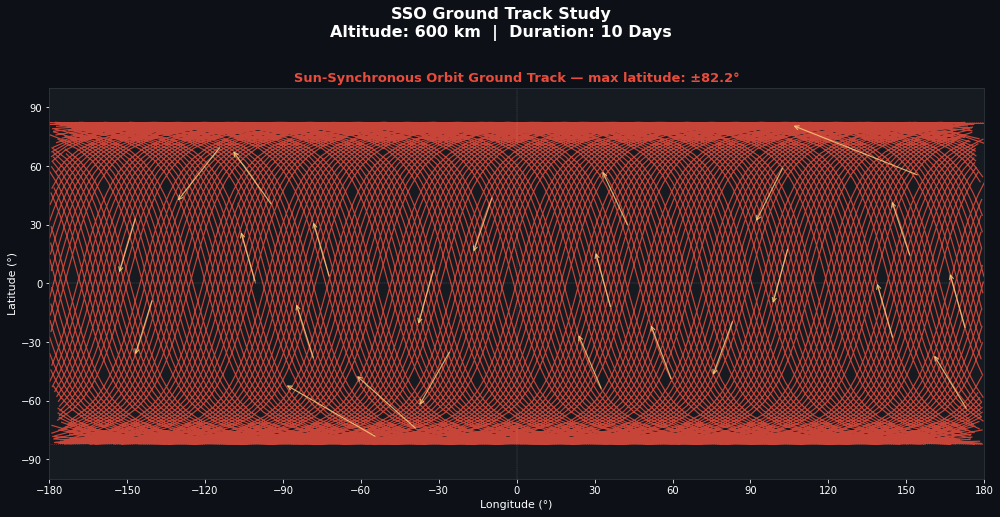

Max latitude: ±82.23°


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import os

output_dir = r'D:\Space Softwares\GMAT Project\Elliptical Orbit + SSO Analysis\Output'
filepath = os.path.join(output_dir, 'SSO_data.txt')

df = pd.read_csv(filepath, sep=r'\s+', skiprows=1,
                  names=['ElapsedSecs', 'RMAG', 'Lat', 'Lon', 'RAAN', 'VX', 'VY', 'VZ'])

fig, ax = plt.subplots(1, 1, figsize=(14, 7), facecolor='#0D1117')
ax.set_facecolor('#161B22')

# Break the line wherever longitude jumps (wraps around ±180°)
lon = df['Lon'].values
lat = df['Lat'].values
jump = np.abs(np.diff(lon)) > 180
lon_seg = np.insert(lon.astype(float), np.where(jump)[0] + 1, np.nan)
lat_seg = np.insert(lat.astype(float), np.where(jump)[0] + 1, np.nan)

ax.plot(lon_seg, lat_seg, color='#E74C3C', linewidth=1.2, alpha=0.85)

# Arrow markers along the track to show direction of travel (every ~100th point)
step = 100
ax.quiver(lon[:-step:step], lat[:-step:step],
          lon[step::step] - lon[:-step:step], lat[step::step] - lat[:-step:step],
          color='#FFD27D', scale_units='xy', angles='xy', scale=1,
          width=0.003, headwidth=4, headlength=5, alpha=0.0)  # invisible base, real arrows below

# Cleaner approach: small triangular direction markers every N points
for i in range(0, len(lon) - 5, 300):
    dx = lon[i+5] - lon[i]
    if abs(dx) < 50:  # skip wrap-around segments
        ax.annotate('', xy=(lon[i+5], lat[i+5]), xytext=(lon[i], lat[i]),
                    arrowprops=dict(arrowstyle='->', color='#FFD27D', lw=1.2, alpha=0.8))

ax.axhline(0, color='white', linewidth=0.4, alpha=0.3, linestyle='--')
ax.axvline(0, color='white', linewidth=0.4, alpha=0.3, linestyle='--')

max_lat = df['Lat'].max()
ax.axhline(max_lat,  color='#E74C3C', linewidth=0.8, alpha=0.5, linestyle=':')
ax.axhline(-max_lat, color='#E74C3C', linewidth=0.8, alpha=0.5, linestyle=':')

ax.set_xlim(-180, 180)
ax.set_ylim(-100, 100)
ax.set_xlabel('Longitude (°)', color='white', fontsize=11)
ax.set_ylabel('Latitude (°)', color='white', fontsize=11)
ax.set_title(f'Sun-Synchronous Orbit Ground Track — max latitude: ±{max_lat:.1f}°',
             color='#E74C3C', fontsize=13, fontweight='bold')
ax.tick_params(colors='white')
ax.xaxis.set_major_locator(mticker.MultipleLocator(30))
ax.yaxis.set_major_locator(mticker.MultipleLocator(30))
for spine in ax.spines.values():
    spine.set_edgecolor('#30363D')

fig.suptitle('SSO Ground Track Study\nAltitude: 600 km  |  Duration: 10 Days',
             fontsize=16, fontweight='bold', y=1.02, color='white')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'SSO_Study.png'), dpi=150, bbox_inches='tight', facecolor='#0D1117')
plt.show()
print(f'Max latitude: ±{max_lat:.2f}°')

RAAN Shift Study

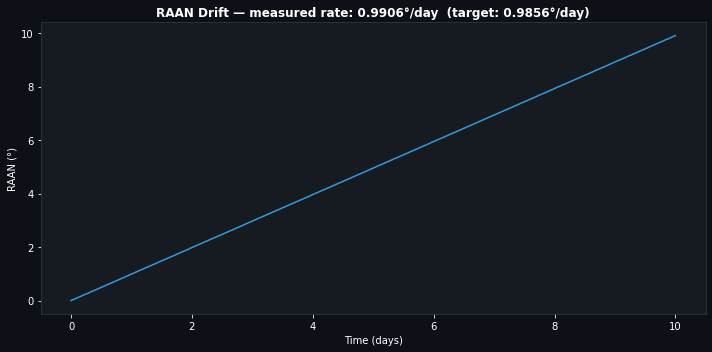

Measured RAAN drift rate: 0.9906 deg/day
Target sun-sync rate:     0.9856 deg/day


In [20]:
days = df['ElapsedSecs'] / 86400
raan_rate = (df['RAAN'].iloc[-1] - df['RAAN'].iloc[0]) / (days.iloc[-1] - days.iloc[0])

fig, ax = plt.subplots(figsize=(10, 5), facecolor='#0D1117')
ax.set_facecolor('#161B22')
ax.plot(days, df['RAAN'], color='#3498DB', linewidth=1.5)
ax.set_xlabel('Time (days)', color='white')
ax.set_ylabel('RAAN (°)', color='white')
ax.set_title(f'RAAN Drift — measured rate: {raan_rate:.4f}°/day  (target: 0.9856°/day)',
             color='white', fontweight='bold')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('#30363D')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'RAAN_drift.png'), dpi=150, facecolor='#0D1117')
plt.show()
print(f'Measured RAAN drift rate: {raan_rate:.4f} deg/day')
print(f'Target sun-sync rate:     0.9856 deg/day')